# EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load data
df = pd.read_csv('/Users/eb2007/playground/bullpy/c4_play2/data/processed/YBT_processed.csv')

# check for class balance and key stats
print(df['autism_target'].value_counts())
print(df.describe())

autism_target
0    23447
1      758
Name: count, dtype: int64
                age        eq10_1        eq10_2        eq10_3        eq10_4  \
count  24205.000000  24205.000000  24205.000000  24205.000000  24205.000000   
mean      24.740219      3.159017      3.047717      2.130634      2.944887   
std       17.533777      0.645047      0.705231      0.807207      0.676728   
min        0.000000      1.000000      1.000000      1.000000      1.000000   
25%       16.000000      3.000000      3.000000      2.000000      3.000000   
50%       22.000000      3.000000      3.000000      2.000000      3.000000   
75%       36.000000      4.000000      3.000000      2.000000      3.000000   
max      118.000000      4.000000      4.000000      4.000000      4.000000   

             eq10_5        eq10_6        eq10_7        eq10_8        eq10_9  \
count  24205.000000  24205.000000  24205.000000  24205.000000  24205.000000   
mean       2.190746      3.078537      2.003222      2.271638      3

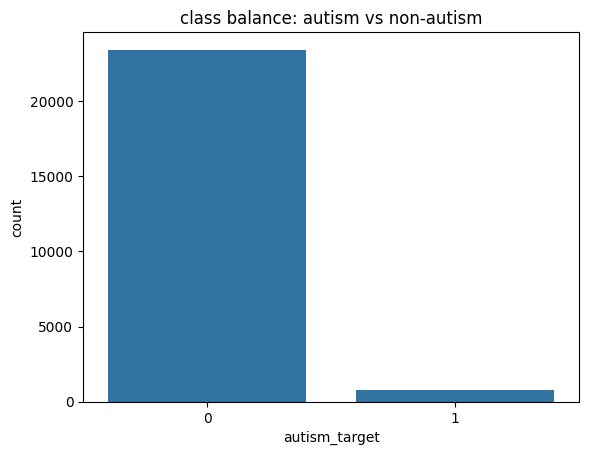

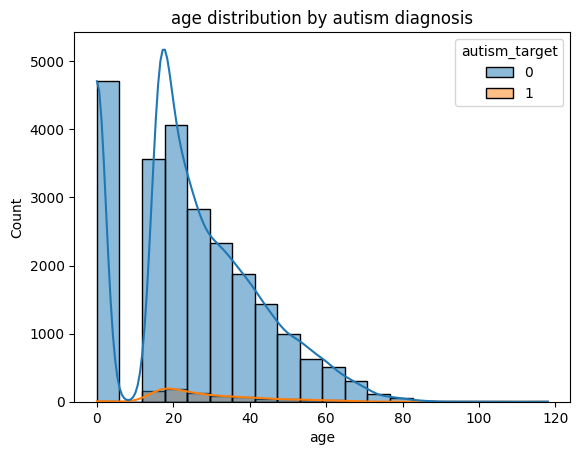

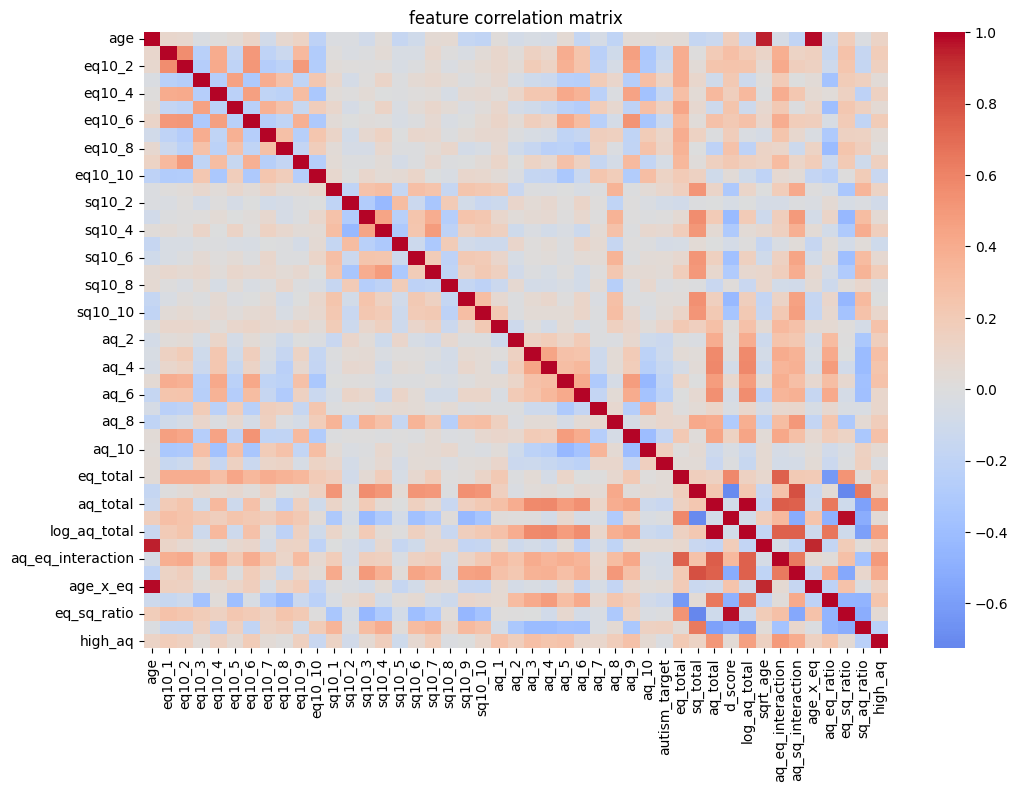

In [2]:
# class balance 
sns.countplot(x='autism_target', data=df)
plt.title('class balance: autism vs non-autism')
plt.show()

# age distribution by autism status
sns.histplot(data=df, x='age', hue='autism_target', bins=20, kde=True)
plt.title("age distribution by autism diagnosis")
plt.show()

# feature correlation - filter to numeric columns only to avoid conversion error
numeric_cols = df.select_dtypes(include=['number']).columns
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm', center=0)
plt.title('feature correlation matrix')
plt.show()


In [3]:
# compare feature means by group

group_means = df.groupby('autism_target').mean(numeric_only=True)
print(group_means.T)

autism_target               0           1
age                 24.612701   28.684697
eq10_1               3.176483    2.618734
eq10_2               3.063206    2.568602
eq10_3               2.111955    2.708443
eq10_4               2.964900    2.325858
eq10_5               2.171323    2.791557
eq10_6               3.094810    2.575198
eq10_7               1.987589    2.486807
eq10_8               2.254617    2.798153
eq10_9               3.134815    2.939314
eq10_10              2.736981    3.364116
sq10_1               3.027509    3.378628
sq10_2               2.841003    2.470976
sq10_3               2.780313    2.824538
sq10_4               2.210688    2.550132
sq10_5               2.801595    2.530343
sq10_6               2.849874    3.022427
sq10_7               2.205101    2.360158
sq10_8               2.194268    2.089710
sq10_9               2.729432    2.854881
sq10_10              2.838572    3.000000
aq_1                 3.105557    3.496042
aq_2                 2.797458    2

# prepare data for modelling 

In [4]:
# define features and target
x =df.drop(columns=['autism_target'])
y = df['autism_target']

In [5]:
# Define target variable
y = df['autism_target']

# Define features by dropping target column
X = df.drop(columns=['autism_target'])

from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# baseline model

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify categorical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns
numeric_cols = X_train.select_dtypes(include=['number']).columns

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Create model pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Train model
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

# Evaluate model
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred)}")


              precision    recall  f1-score   support

           0       0.97      1.00      0.98      4689
           1       0.67      0.07      0.12       152

    accuracy                           0.97      4841
   macro avg       0.82      0.53      0.55      4841
weighted avg       0.96      0.97      0.96      4841

[[4684    5]
 [ 142   10]]
Accuracy: 0.9696343730634166
ROC AUC: 0.5323615741208428


# feature importance 

age_x_eq             0.047808
aq_eq_ratio          0.042467
sq_aq_ratio          0.040368
aq_eq_interaction    0.038500
eq_sq_ratio          0.037514
age                  0.036682
sqrt_age             0.036077
aq_sq_interaction    0.034798
aq_6                 0.034644
d_score              0.027579
eq_total             0.026810
aq_9                 0.026445
aq_2                 0.024891
sq_total             0.023920
aq_5                 0.023864
aq_total             0.023366
log_aq_total         0.022650
eq10_4               0.020998
aq_8                 0.020740
aq_1                 0.020139
dtype: float64


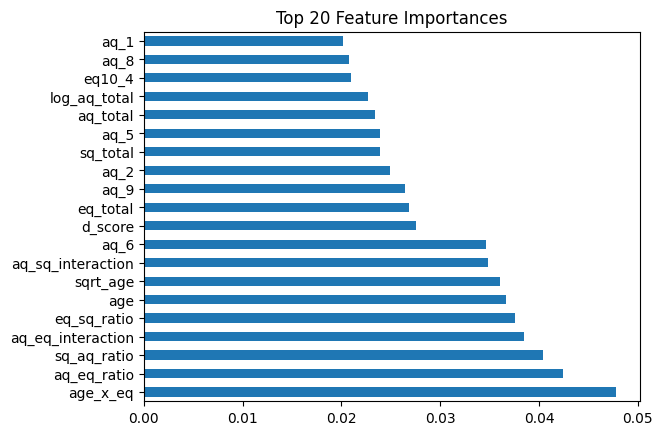

In [8]:
# Extract the classifier from the pipeline
clf = pipeline.named_steps['classifier']

# Get feature names after preprocessing
preprocessor = pipeline.named_steps['preprocessor']
feature_names = numeric_cols.tolist()
if len(categorical_cols) > 0:
    # Get the one-hot encoded feature names
    ohe = preprocessor.named_transformers_['cat']
    feature_names += list(ohe.get_feature_names_out(categorical_cols))

# Get feature importances
importances = clf.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print(feat_imp.head(20))

# Plot
import matplotlib.pyplot as plt
feat_imp.head(20).plot(kind='barh')
plt.title('Top 20 Feature Importances')
plt.show()
